# Wavelet comparison of shoreline models: method demo

This notebook runs the whole comparison on **synthetic data with known answers**, so
you can see what each figure and metric says before using real ShoreShop3 data.

* A "true" shoreline has four processes: a long-term trend, a seasonal cycle,
  interannual (climate-mode-like) variability, and storm erosion with ~45-day recovery.
* Observations sample it like satellite shorelines (every 5-16 days, cloud losses,
  3 m noise, and six months with no data in 2014).
* Three models each get different processes right:
  * **Model A** (equilibrium-type): storms and seasonal cycle right, storm response 40 % too weak, no interannual signal
  * **Model B** (long-term): no storms, seasonal cycle 40 days late and 30 % weak, interannual signal right
  * **Model C** (hybrid): everything present, but recovers from storms too fast (12 days) and adds its own short-period noise

The question the method has to answer: *which model is good at which time scale?*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shoreshop3 import wavelets as wv
from shoreshop3 import plotting as sp
from shoreshop3.timeseries import regularize
from shoreshop3.paths import INTERIM

sp.use_style()
rng = np.random.default_rng(2026)
N_MC = 100          # Monte Carlo surrogates for coherence significance (use >= 300 for final results)
SIG_CACHE = INTERIM / "wtc_sig"
S0 = 8.0            # smallest period analysed (days): ~2 x the typical observation spacing
TICKS = [8, 16, 30, 91, 182, 365, 730, 1461, 2922]   # period axis ticks, days

## 1. Synthetic truth, models and observations

In [2]:
time = pd.date_range("2008-01-01", "2023-12-31", freq="D")
n = time.size
t_yr = np.arange(n) / 365.25
doy = time.dayofyear.to_numpy()

# storms: Poisson impulses, more frequent in winter, sizes ~ exponential (mean 8 m)
p_storm = 5 / 365.25 * (1 + 0.8 * np.cos(2 * np.pi * (doy - 15) / 365.25))
storms = np.where(rng.random(n) < p_storm, rng.exponential(8.0, n), 0.0)

def respond(impulses, tau_days):
    """Instant erosion followed by exponential recovery with time scale tau."""
    kernel = np.exp(-np.arange(int(8 * tau_days)) / tau_days)
    return -np.convolve(impulses, kernel)[:n]

def seasonal_cycle(amplitude, lag_days=0.0):
    return amplitude * np.cos(2 * np.pi * (doy - 225 - lag_days) / 365.25)  # widest beach mid-August

trend = -0.4 * t_yr
interannual = 4.0 * np.sin(2 * np.pi * t_yr / 3.7 + 0.6) + 3.0 * np.sin(2 * np.pi * t_yr / 5.3 + 2.0)
truth = 60 + trend + seasonal_cycle(8.0) + interannual + respond(storms, 45)

models = {
    "Model A": 60 + trend + seasonal_cycle(8.0) + 0.6 * respond(storms, 45),
    "Model B": 60 - 0.3 * t_yr + seasonal_cycle(5.6, lag_days=40) + interannual,
    "Model C": (60 + trend + seasonal_cycle(8.0) + interannual + respond(storms, 12)
                + 2.5 * wv.ar1_noise(n, 0.9, rng)),
}

# satellite-like observations: a pass every 5-16 days, 30 % lost to clouds, 3 m noise, no data Mar-Aug 2014
idx = np.cumsum(rng.integers(5, 17, size=n))
idx = idx[idx < n]
idx = idx[rng.random(idx.size) > 0.3]
idx = idx[~((time[idx] >= "2014-03-01") & (time[idx] < "2014-09-01"))]
obs_time, obs_x = time[idx], truth[idx] + 3.0 * rng.standard_normal(idx.size)
print(f"{n} model days, {idx.size} observations (median spacing {np.median(np.diff(idx)):.0f} days)")

5844 model days, 381 observations (median spacing 13 days)


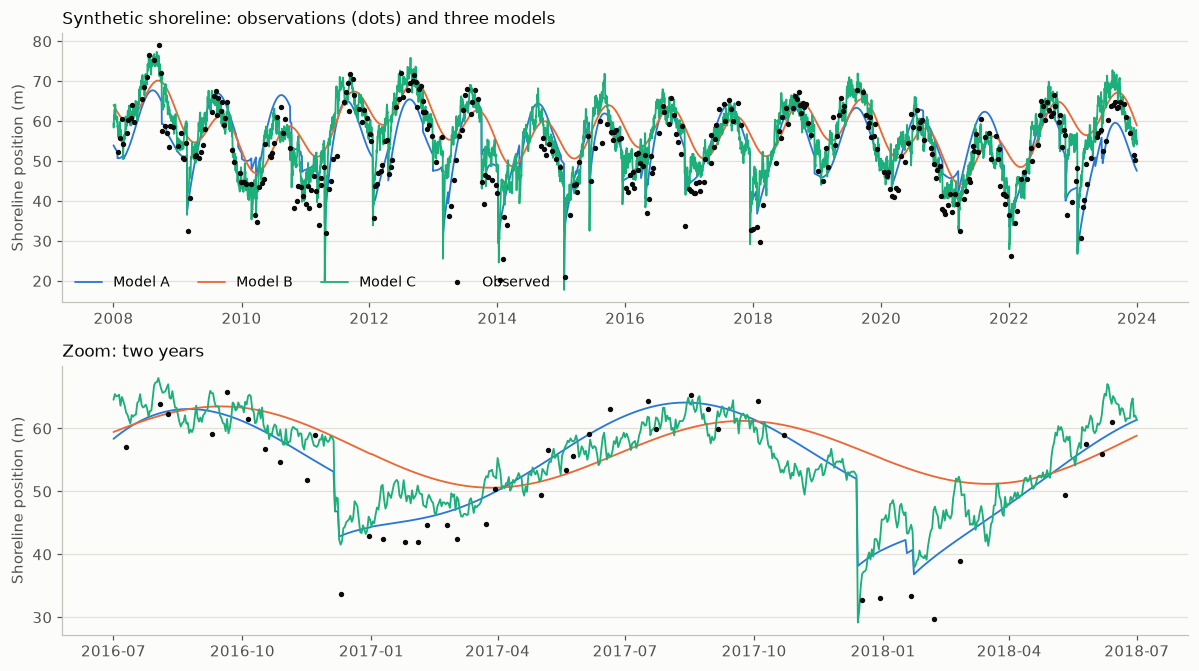

In [3]:
colors = sp.model_colors(models)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), gridspec_kw={"height_ratios": [1, 1]})
for ax, (t0, t1) in zip(axes, [(time[0], time[-1]), (pd.Timestamp("2016-07-01"), pd.Timestamp("2018-07-01"))]):
    win = (time >= t0) & (time <= t1)
    owin = (obs_time >= t0) & (obs_time <= t1)
    for name, x in models.items():
        ax.plot(time[win], x[win], color=colors[name], linewidth=1.2, label=name)
    ax.plot(obs_time[owin], obs_x[owin], "o", markersize=2.5, color=sp.INK, label="Observed")
    ax.set_ylabel("Shoreline position (m)")
    ax.grid(axis="y")
axes[0].set_title("Synthetic shoreline: observations (dots) and three models")
axes[1].set_title("Zoom: two years")
axes[0].legend(loc="lower left", ncol=4)
fig.tight_layout()

## 2. Observations on a regular grid

The CWT needs evenly spaced data without gaps. `regularize` interpolates the
observations onto the model's daily grid and flags gaps longer than 45 days;
a wavelet coefficient is masked when more than 25 % of its energy falls on a
flagged gap, so a short gap only removes short periods and the six-month gap in
2014 also removes the seasonal scale around it. Sampling every ~13 days means
periods shorter than ~3-4 weeks are not really observed: the analysis starts at
8 days and the shortest band at 20 days.

In [4]:
reg = regularize(obs_time, obs_x, "1D", max_gap="45D", start=time[0], end=time[-1])
assert np.array_equal(reg.time, time.to_numpy())
obs = reg.values
print(f"dt = {reg.dt} day; interpolated days: {reg.filled.mean():.0%}; "
      f"flagged as long gaps: {reg.gap.sum()} days")

dt = 1.0 day; interpolated days: 93%; flagged as long gaps: 484 days


## 3. Where is the observed variance? Wavelet power of the observations

Colour: power relative to white noise (log2). Black contour: 95 % significance
against AR1 red noise. The washed-out area is the cone of influence (record ends)
plus the 2014 gap; those coefficients are unreliable and excluded from all
statistics. Shoreline records are very persistent (AR1 close to 1), so the
red-noise test is lenient at short periods: read it as a guide.

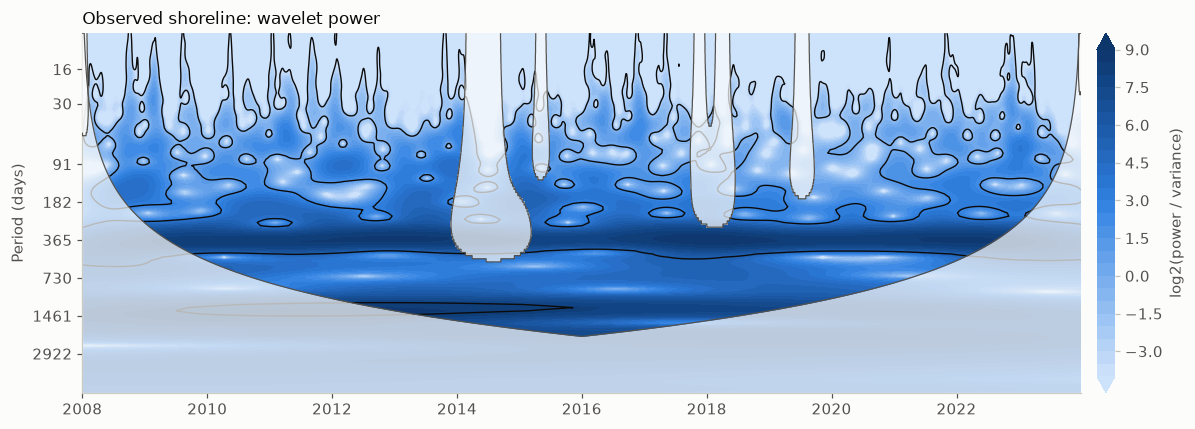

In [5]:
res_obs = wv.cwt(obs, reg.dt, s0=S0, invalid=reg.gap)
fig, ax = plt.subplots(figsize=(11, 4))
sp.plot_power(res_obs, time=time, ax=ax, alpha=wv.ar1(obs), period_ticks=TICKS,
              period_label="Period (days)", title="Observed shoreline: wavelet power")
fig.tight_layout()

## 4. Does each model put variance at the right periods?

Time-averaged wavelet power (outside the cone of influence) in m². A model
line below the observed line at some period is too damped there; above it, too active.

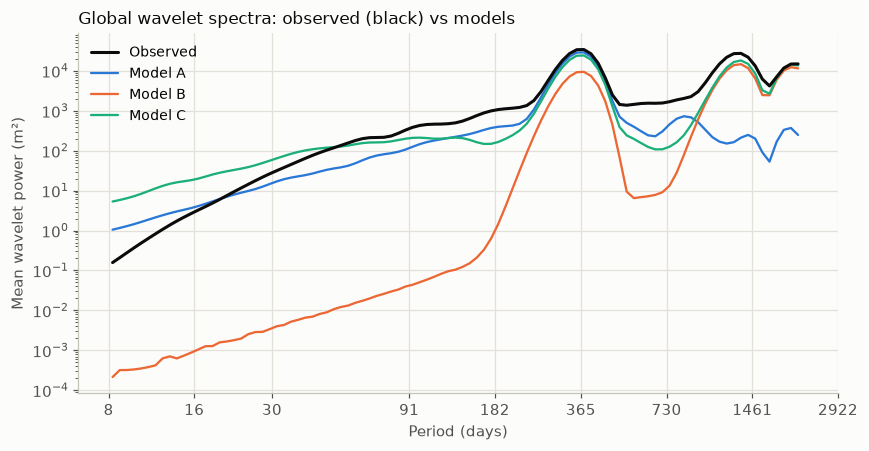

In [6]:
cwts = {"obs": res_obs, **{name: wv.cwt(x, 1.0, s0=S0) for name, x in models.items()}}
fig, ax = plt.subplots(figsize=(8, 4.2))
sp.plot_global_spectra(cwts, obs_key="obs", period_ticks=TICKS, period_label="Period (days)",
                       title="Global wavelet spectra: observed (black) vs models")
fig.tight_layout()

## 5. When and at which periods do models co-vary with the observations?

Squared wavelet coherence (independent of amplitude). Black contour: 95 %
significance from red-noise Monte Carlo surrogates. Arrows (only where the
coherence is significant): right = in phase, left = anti-phase,
**down = model lags the observations**, up = model leads.

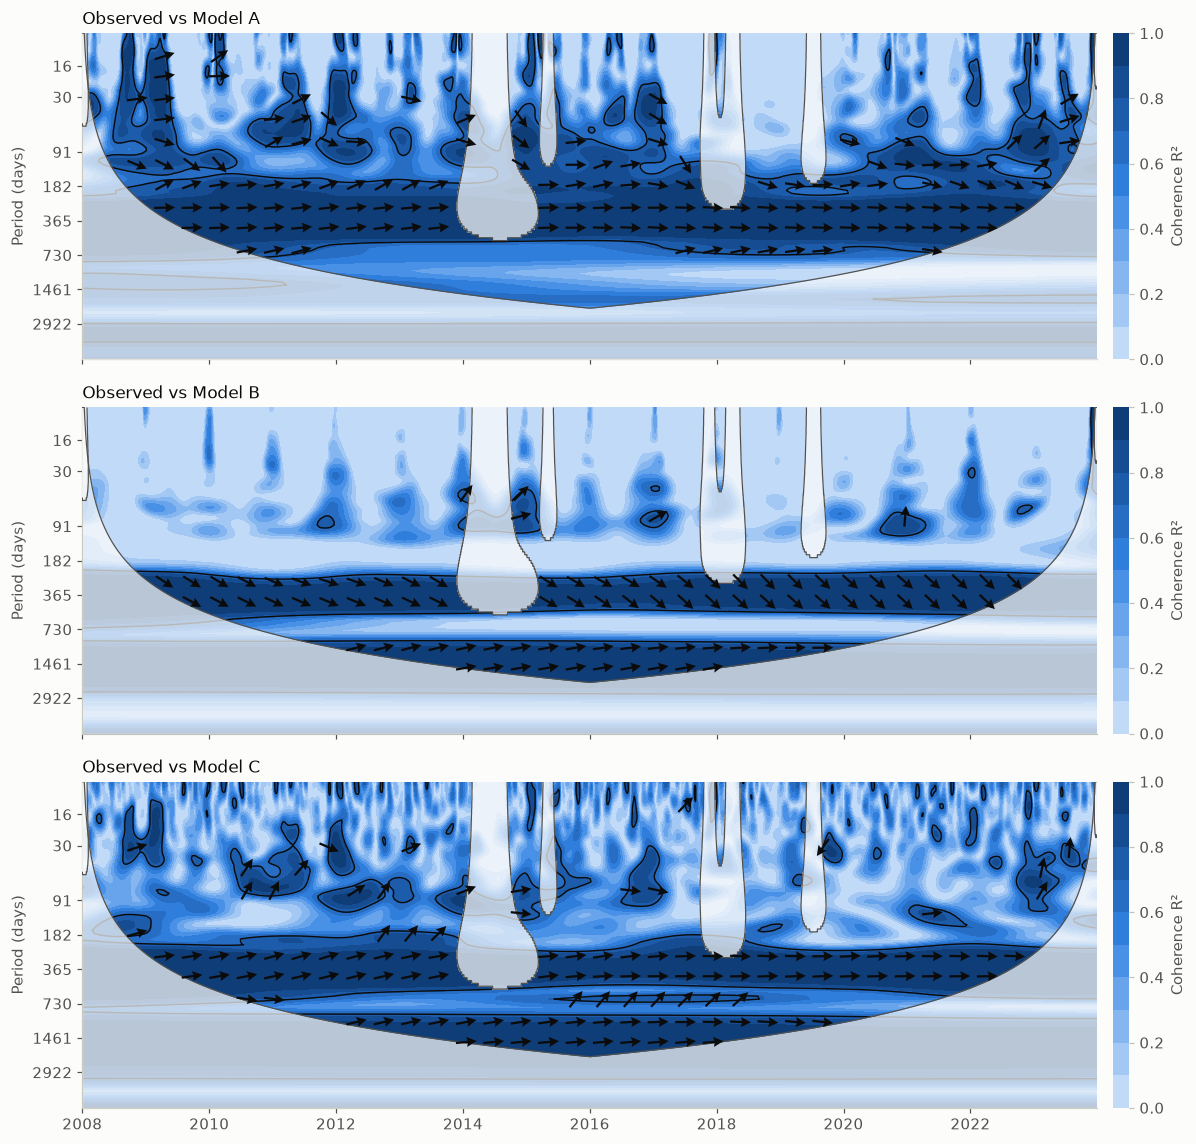

In [7]:
a_obs = wv.ar1(obs)
fig, axes = plt.subplots(3, 1, figsize=(11, 10.5), sharex=True)
for ax, (name, x) in zip(axes, models.items()):
    coh = wv.wavelet_coherence(obs, x, 1.0, s0=S0, invalid_x=reg.gap)
    sig = wv.coherence_significance(n, 1.0, a_obs, wv.ar1(x), s0=S0, n_surrogates=N_MC,
                                    cache_dir=SIG_CACHE)
    sp.plot_coherence(coh, time=time, ax=ax, sig=sig, period_ticks=TICKS,
                      period_label="Period (days)", title=f"Observed vs {name}")
fig.tight_layout()

## 6. Skill by time scale

`compare_models` reconstructs each band from the wavelet coefficients and
compares band-limited signals where the whole band is trustworthy
(`valid_frac` = share of the record). How to read the columns:

* `var_frac_obs`: how much of the observed variance sits in the band (how much the band matters)
* `std_ratio`: model / observed amplitude in the band (< 1 too damped, > 1 too active)
* `corr`, `nse`: skill of the band-limited signals (NSE 1 = perfect, 0 = no better than the mean)
* `mean_rsq`, `sig_frac`: wavelet coherence, i.e. timing regardless of amplitude
* `lag`: timing error in days from the coherent part of the band (+ = model late)

In [8]:
BANDS = {
    "Storm\n20-90 d": (20, 90),
    "Sub-seasonal\n3-6 mo": (90, 182),
    "Seasonal\n0.5-1.5 yr": (182, 548),
    "Interannual\n1.5-4 yr": (548, 1461),
}
skill = wv.compare_models(obs, models, 1.0, BANDS, s0=S0, invalid_obs=reg.gap,
                          n_surrogates=N_MC, cache_dir=SIG_CACHE)
cols = ["model", "band", "valid_frac", "var_frac_obs", "std_ratio", "corr", "nse",
        "mean_rsq", "sig_frac", "phase_deg", "lag"]
skill[cols].assign(band=skill["band"].str.replace("\n", " ")).round(2)

,model,band,valid_frac,var_frac_obs,std_ratio,corr,nse,mean_rsq,sig_frac,phase_deg,lag
0,Model A,Storm 20-90 d,0.83,0.05,0.60,0.59,0.34,0.45,0.27,-4.41,-0.51
1,Model A,Sub-seasonal 3-6 mo,0.76,0.06,0.62,0.74,0.53,0.70,0.61,3.99,0.98
2,Model A,Seasonal 0.5-1.5 yr,0.63,0.59,0.90,0.99,0.96,0.94,0.99,-0.95,-0.90
3,Model A,Interannual 1.5-4 yr,0.34,0.13,0.26,0.28,-0.00,0.49,0.18,-5.89,-9.75
4,Model B,Storm 20-90 d,0.83,0.05,0.00,0.07,0.00,0.18,0.03,NaN,NaN
5,Model B,Sub-seasonal 3-6 mo,0.76,0.06,0.01,0.22,0.00,0.14,0.02,NaN,NaN
6,Model B,Seasonal 0.5-1.5 yr,0.63,0.59,0.52,0.80,0.55,0.74,0.71,34.68,34.21
7,Model B,Interannual 1.5-4 yr,0.34,0.13,0.59,0.88,0.67,0.49,0.37,-9.69,-33.40
8,Model C,Storm 20-90 d,0.83,0.05,1.03,0.41,-0.22,0.42,0.18,-31.79,-5.51
9,Model C,Sub-seasonal 3-6 mo,0.76,0.06,0.64,0.39,0.10,0.42,0.11,-15.73,-4.82


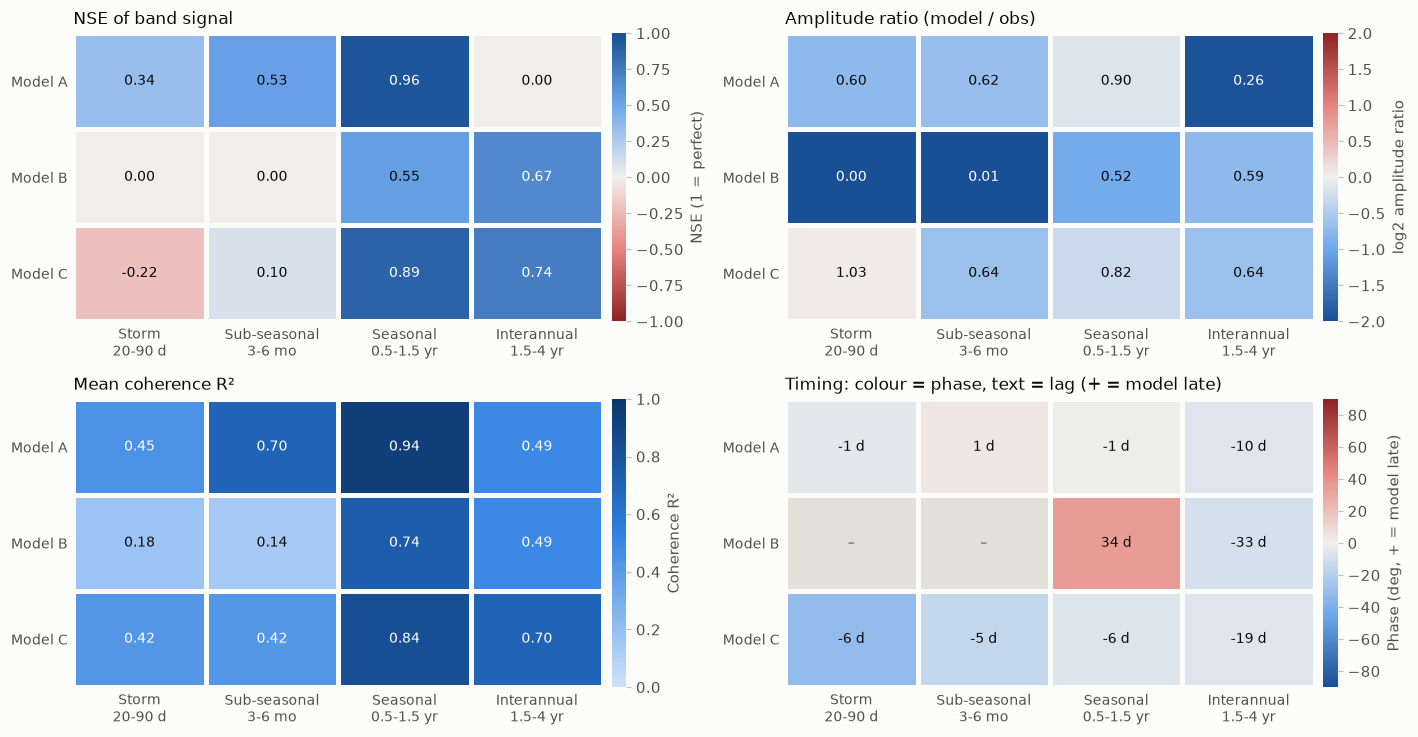

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.8))
specs = [("nse", "{:.2f}", None, "NSE of band signal"),
         ("std_ratio", "{:.2f}", None, "Amplitude ratio (model / obs)"),
         ("mean_rsq", "{:.2f}", None, "Mean coherence R²"),
         ("phase_deg", "{:.0f} d", "lag", "Timing: colour = phase, text = lag (+ = model late)")]
for ax, (metric, fmt, text, title) in zip(axes.flat, specs):
    sp.plot_skill_heatmap(skill, metric, ax=ax, fmt=fmt, text_metric=text, title=title)
fig.tight_layout()

Periods longer than ~6 years cannot be evaluated in a 16-year record (cone of
influence), so compare long-term behaviour through trends instead:

In [10]:
def slope(x, exclude=None):
    keep = np.ones(n, bool) if exclude is None else ~exclude
    return np.polyfit(t_yr[keep], x[keep], 1)[0]

trends = pd.Series({"Observed": slope(obs, reg.gap), **{k: slope(v) for k, v in models.items()}})
trends.round(2).rename("linear trend (m/yr)").to_frame()

,linear trend (m/yr)
Observed,-0.28
Model A,-0.32
Model B,-0.20
Model C,-0.25


### What the method found (compare with how the models were built)

* **Seasonal band** (59 % of the observed variance): all three models are coherent with
  the observations. Model A is best (NSE 0.96, amplitude 0.90, no lag). Model B has the
  right period but half the amplitude and is **34 days late** (the planted lag was 40 days;
  the observed seasonal signal also contains the winter storm season, which B lacks).
* **Storm band** (5 %): Model A has the right timing but **60 % of the amplitude** (exactly
  the planted factor 0.6). Model B has no storm signal at all (amplitude 0, no significant
  coherence, so no lag is reported). Model C has the right amplitude (1.03) but negative
  NSE: it recovers too fast, so it runs ~6 days early (-32 deg), and it adds its own noise.
* **Interannual band** (13 %): Models B and C capture the climate-mode signal (NSE 0.67 and
  0.74). Model A's amplitude ratio is 0.26 and its NSE 0: its only interannual variability
  comes from storm clustering, which is why its coherence is moderate (0.49) but its skill is nil.
* **Trend**: the planted trend is -0.4 m/yr, but a 16-year regression on the observations
  gives -0.28 m/yr, because interannual variability biases short-record trends.

No single model is "best". A is the storm and seasonal model, B and C carry the
interannual signal, and the metrics recover the strengths and weaknesses that were
planted. Amplitude (`std_ratio`), timing (`mean_rsq`, `lag`) and overall skill (`nse`)
tell different parts of the story, so read them together.

## 7. The same tools along the coast

For alongshore scales, `dt` is the transect spacing. Here a 40 km coast with
50 m transects: an 8 km large-scale undulation, 1.6 km shoreline sand waves and
local noise. The model gets the large scale, but its sand waves are weak and
sit 300 m further along the coast.

In [11]:
dx = 50.0                                   # m between transects
xa = np.arange(800) * dx                    # alongshore distance (m)
large = 12 * np.sin(2 * np.pi * xa / 8_000)
sandwaves = 6 * np.sin(2 * np.pi * xa / 1_600)
obs_along = large + sandwaves + 2 * rng.standard_normal(xa.size)
model_along = 0.9 * large + 2.5 * np.sin(2 * np.pi * (xa - 300) / 1_600)

BANDS_X = {"Local < 0.5 km": (0, 500), "Sand waves 1-3 km": (1_000, 3_000),
           "Large scale 5-10 km": (5_000, 10_000)}
along = wv.band_skill(obs_along, model_along, dx, BANDS_X)
along[["band", "valid_frac", "var_frac_obs", "std_ratio", "corr", "nse", "mean_rsq", "lag"]].round(2)

,band,valid_frac,var_frac_obs,std_ratio,corr,nse,mean_rsq,lag
0,Local < 0.5 km,0.96,0.03,0.00,0.01,0.00,0.01,NaN
1,Sand waves 1-3 km,0.80,0.19,0.41,0.39,0.15,0.87,286.77
2,Large scale 5-10 km,0.32,0.64,0.88,1.00,0.99,1.00,-4.28


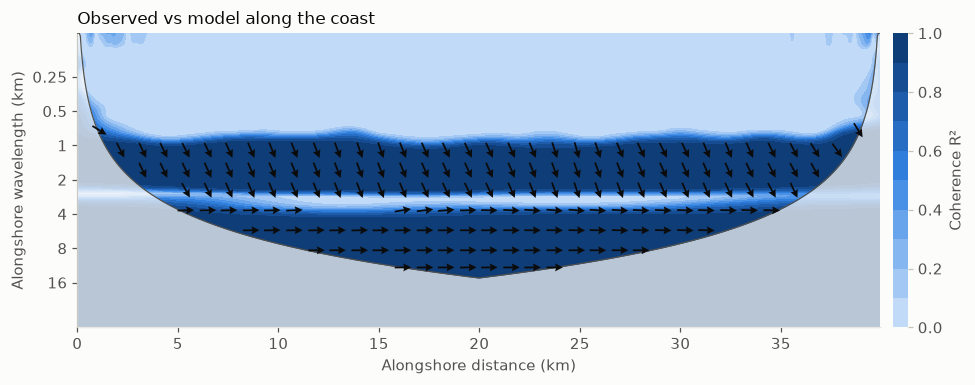

In [12]:
coh_x = wv.wavelet_coherence(obs_along, model_along, dx)
fig, ax = plt.subplots(figsize=(9, 3.6))
sp.plot_coherence(coh_x, time=xa / 1000, ax=ax, period_scale=1 / 1000, period_ticks=[0.25, 0.5, 1, 2, 4, 8, 16],
                  period_label="Alongshore wavelength (km)", title="Observed vs model along the coast")
ax.set_xlabel("Alongshore distance (km)")
fig.tight_layout()

Reading: the 5-10 km band (64 % of the alongshore variance) is right (NSE 0.99, amplitude
0.88 vs the planted 0.9, no lag). The sand-wave band is coherent (R² 0.87), but the
amplitude ratio is 0.41 (planted 2.5 / 6 = 0.42) and the lag is +287 m (planted 300 m): the
model makes the right features, too weak and in the wrong place. Below 0.5 km the model has
no variance, so amplitude and coherence are ~0 and no lag is reported.

## 8. Applying this to ShoreShop3

1. `scripts/globus_sync.sh`, then `python scripts/local_inventory.py`: see what each team submitted.
2. Write one reader per submission format that returns `model x transect x time` (the template tells us the target).
3. For each transect: `regularize` the observations, run `compare_models` with agreed bands, and stack the tables.
4. Summarise by model and band (median over transects), and map the metrics along the coast.
5. Add forcing-response coherence (waves / water level vs shoreline) for the observations and each model.